In [4]:
"""
Quantum-circuit construction for U_{v_r} (Section 4.1: “Construction of U_{v_r}”).

This module builds circuits that, for each basis index j, prepare a single
computational qubit whose |0⟩-amplitude equals the Chebyshev term (v_r)_j:

  • r = 0: (v_0)_j = 1/2  (constant case; Algorithm 2 / Proposition 9)
  • r ≥ 1: (v_r)_j = T_r(x_j), where
        x_j = 2j / N − 1,  N = 2^n
    (Algorithm 3 / Proposition 11)

========================================================================
REGISTER AND FIXED-POINT CONVENTION (IMPORTANT)
========================================================================
Qiskit integer arithmetic interprets a k-qubit register xreg = QuantumRegister(k)
as an unsigned integer with:
    xreg[0]   = least-significant bit (LSB),
    xreg[k-1] = most-significant bit (MSB).

We represent a real number x ∈ (0, 1) by storing an unsigned integer v in xreg:
    v = Σ_{j=0}^{k-1} x_j · 2^j     (x_j ∈ {0,1})
    x = v / 2^k

Therefore:
    xreg[0]   has fractional weight 2^{-k} (smallest step),
    xreg[k-1] has fractional weight 2^{-1} (largest fractional bit).
"""

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import CDKMRippleCarryAdder, XGate
from qiskit.quantum_info import Statevector


def U_v0_circuit(n: int) -> QuantumCircuit:
    """
    Construct the circuit U_{v0} corresponding to the r = 0 Chebyshev case.

    This routine prepares a uniform superposition over index states |j⟩ on an
    n-qubit register and initializes a single computational qubit whose |0⟩
    amplitude equals (v_0)_j = 1/2 for all j, as specified in Algorithm 2.

    Args:
        n: Number of qubits in the index register.

    Returns:
        A QuantumCircuit on 1+n qubits implementing U_{v0}.

    Raises:
        ValueError: If n < 1.
    """
    if n < 1:
        raise ValueError("n must be >= 1")

    qc = QuantumCircuit(1 + n, name="U_v0")

    # Prepare uniform superposition over j.
    for q in range(1, 1 + n):
        qc.h(q)

    # Prepare computational qubit with |0>-amplitude equal to 1/2.
    qc.rx(-2 * np.pi / 3, 0)
    
    return qc


def uneg(k: int) -> QuantumCircuit:
    """
    Implements |x> -> |1-x> on a k-qubit fixed-point fraction register (little-endian).
    Construction:
      1) bitwise complement
      2) add 1 to the integer value (i.e. add 2^{-k} fractionally)
    """
    if k < 1:
        raise ValueError("k must be >= 1")

    x = QuantumRegister(k, "x")
    qc = QuantumCircuit(x, name=f"Uneg_{k}")

    # Step 1: bitwise complement
    qc.x(x)

    # Step 2: increment by 1 (must be done MSB -> LSB to avoid control corruption)
    for i in range(k - 1, 0, -1):
        qc.mcx(list(x[:i]), x[i])
    qc.x(x[0])

    return qc


def U_vr_circuit(n: int, p: int) -> QuantumCircuit:
    """
    Construct the preparatory subcircuit for U_{v_r} in the case r ≥ 1.

    This routine performs the setup phase used to later encode Chebyshev values
    T_r(x_j) into the amplitude of a single computational qubit. Specifically,
    it:
      (1) prepares a uniform superposition over indices |j⟩ on an n-qubit
          register,
      (2) computes a fixed-point encoding of x_j into an n-qubit workspace, and
      (3) conditionally transforms that encoding based on the most significant
          bit of j, matching the initialization logic in Algorithm 3.

    The auxiliary register xreg is interpreted in the fixed-point convention
    described in the module docstring.

    Args:
        n: Number of qubits in the index register and in the fixed-point x
            workspace.
        p: Number of ancilla qubits reserved for angle/arccos-related workspace.

    Returns:
        A QuantumCircuit on 1 + 2n + p qubits implementing the preparatory steps
        of U_{v_r} (superposition, x_j encoding, and conditional sign/magnitude
        adjustment).

    Raises:
        ValueError: If n < 1 or p < 0.
    """
    if n < 1:
        raise ValueError("n must be >= 1")
    if p < 0:
        raise ValueError("p must be >= 0")

    comp = QuantumRegister(1, "c")        # Computational qubit
    jreg = QuantumRegister(n, "j")        # Index register
    xreg = QuantumRegister(n, "x")        # Fixed-point workspace for x_j
    treg = QuantumRegister(p, "theta")    # Ancillas for angle workspace
    qc = QuantumCircuit(comp, jreg, xreg, treg, name="U_vr")

    # Prepare uniform superposition over j.
    qc.h(jreg)

    # Copy lower (n−1) bits of j into the magnitude bits of x.
    for k in range(n - 1):
        qc.cx(jreg[k], xreg[k])

    # Identify control and target subsets.
    j_msb = jreg[n - 1]          # Most significant bit of j
    x_mag = list(xreg[: n - 1])  # Magnitude bits of x
    x_sgn = xreg[n - 1]          # Sign bit of x

    # If j_{n−1} = 0, apply x_mag → 1 − x_mag.
    uneg_gate = uneg(n - 1).to_gate()
    c0_uneg = uneg_gate.control(1, ctrl_state="0")
    qc.append(c0_uneg, [j_msb] + x_mag)

    # If j_{n−1} = 0, flip the sign bit.
    c0_x = XGate().control(1, ctrl_state="0")
    qc.append(c0_x, [j_msb, x_sgn])

    qc.barrier()
    return qc

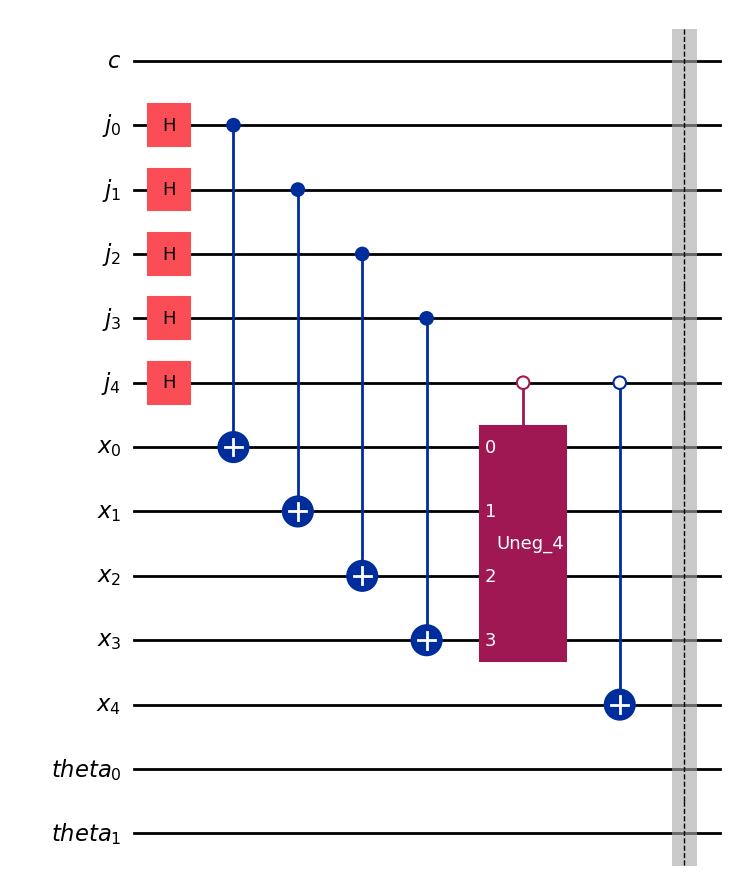

In [5]:
qc = U_vr_circuit(5,2)
qc.draw("mpl")

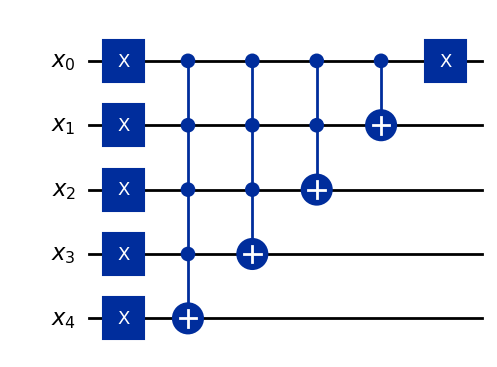

In [6]:
qc = uneg(5) 
qc.draw("mpl")

In [ ]:
import random
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# assumes you already defined uneg(k) exactly as before
# def uneg(k: int) -> QuantumCircuit: ...

def run_single_test(a: int, k: int = 6):
    if not (0 < a < 2**k):
        raise ValueError("Require 0 < a < 2^k so x in (0,1) is representable.")

    gate = uneg(k).to_gate()

    qc = QuantumCircuit(k)

    # prepare |a> on x-register (little-endian: qubit 0 is LSB)
    for i in range(k):
        if (a >> i) & 1:
            qc.x(i)

    qc.append(gate, list(range(k)))

    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities_dict()

    # most-likely output basis state as a bitstring (leftmost = highest qubit index)
    bitstr = max(probs, key=probs.get)

    # convert to integer value v (consistent with Qiskit's bitstring order)
    v_out = int(bitstr, 2)

    expected = (2**k - a)  # since Uneg maps v -> 2^k - v

    print("input integer:", a, "input fraction:", a/(2**k))
    print("output bitstring:", bitstr)
    print("output integer:", v_out, "expected:", expected)
    print("output fraction:", v_out/(2**k), "expected:", expected/(2**k))
    print("PASS" if v_out == expected else "FAIL")
    return v_out, expected


def run_many_tests(k: int = 6, trials: int = 20, seed: int = 0):
    random.seed(seed)
    gate = uneg(k).to_gate()

    for _ in range(trials):
        a = random.randint(1, 2**k - 1)  # exclude 0 to stay in (0,1)

        qc = QuantumCircuit(k)
        for i in range(k):
            if (a >> i) & 1:
                qc.x(i)
        qc.append(gate, list(range(k)))

        bitstr = max(Statevector.from_instruction(qc).probabilities_dict(), key=lambda s: Statevector.from_instruction(qc).probabilities_dict()[s])
        v_out = int(bitstr, 2)
        expected = 2**k - a

        if v_out != expected:
            print(f"FAIL for a={a}: got {v_out}, expected {expected}, bitstr={bitstr}")
            return False

    print(f"All {trials} tests passed for k={k}.")
    return True


# ---- Example: exactly your case ----
k = 6
a = 5  # represents 5/2^6
run_single_test(a, k)

# Optional: random regression tests
run_many_tests(k=6, trials=50, seed=123)

input integer: 5 input fraction: 0.078125
output bitstring: 111011
output integer: 59 expected: 59
output fraction: 0.921875 expected: 0.921875
PASS
